# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ali0678/FlyRank-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [10]:
from google.colab import files

uploaded = files.upload()

Saving content_refresh_anonymized.csv to content_refresh_anonymized.csv


In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("content_refresh_anonymized.csv")

lane_df = (
    df[
        (df["impressions_90d"] > 0) &
        (df["content_age_days"] >= 90)
    ]
    .drop_duplicates(subset="content_id")
    .copy()
)

print("Rows:", len(lane_df))
print("Unique content IDs:", lane_df["content_id"].nunique())

Rows: 30000
Unique content IDs: 30000


## 1. Question

*The research question and the decision it supports.*

Research question: Can observed search and content signals be used to rank pages that are worth reviewing for a content refresh?

Decision: The output supports a content team's decision about which pages to review first when review time is limited.

The result is intended as directional decision-support. It does not claim that refreshing a page will cause better Google performance.

In [12]:
print("Lane: Refresh / Content Opportunity Scoring")
print("Decision: Which pages should be reviewed first?")

Lane: Refresh / Content Opportunity Scoring
Decision: Which pages should be reviewed first?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

I use the FlyRank internship warehouse release. The main tables used are the content dimension and daily content performance data.

The unit of analysis is one content page at a prediction date.

Features are calculated from a prior observation window, while the outcome is measured in a later window. Existing product decisions, client-identifying information, raw URLs, private queries, and other sensitive fields are excluded.

The analysis uses only public-safe, anonymized fields needed for the ranking task.

In [13]:
print("Unit of analysis: one content page at a prediction date")
print("Feature window: prior observation period")
print("Target window: later observation period")
print("Excluded: client-identifying and product-decision fields")

Unit of analysis: one content page at a prediction date
Feature window: prior observation period
Target window: later observation period
Excluded: client-identifying and product-decision fields


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The model uses observable page-level search and content signals such as impressions, sessions, CTR, position, content age, and engagement where available.

The target represents a future observed decline/review outcome rather than a claim about Google's algorithm.

The baseline is a simple rule that gives higher priority to pages with stronger visibility and signs of staleness.

The ML model is evaluated against the baseline on the same held-out data. The validation split keeps the future outcome separate from the feature window. Leakage checks are used to make sure future information and existing product decisions are not used as model features.

In [14]:
features = [
    "impressions",
    "sessions",
    "ctr",
    "avg_position",
    "content_age_days",
    "engagement_rate"
]

print("Candidate features:", features)
print("Baseline: simple staleness + visibility score")
print("Validation: held-out future data")
print("Leakage check: future-window and product-decision fields excluded")

Candidate features: ['impressions', 'sessions', 'ctr', 'avg_position', 'content_age_days', 'engagement_rate']
Baseline: simple staleness + visibility score
Validation: held-out future data
Leakage check: future-window and product-decision fields excluded


In [15]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_score

# Load the starter data
df = pd.read_csv("content_refresh_anonymized.csv")

# Prepare the lane
lane_df = (
    df[
        (df["impressions_90d"] > 0) &
        (df["content_age_days"] >= 90)
    ]
    .drop_duplicates(subset="content_id")
    .copy()
)

# Proxy target
lane_df["is_declining_label"] = (
    lane_df["trend_direction"] == "down"
).astype(int)

print("Rows:", len(lane_df))
print("Positive labels:", lane_df["is_declining_label"].sum())

# Features that are available in the starter data
candidate_features = [
    "impressions_90d",
    "sessions_90d",
    "content_age_days",
    "ctr",
    "avg_position",
    "word_count",
    "engagement_rate"
]

features = [
    col for col in candidate_features
    if col in lane_df.columns
]

print("Features used:", features)

# Remove rows with missing feature/target values
model_df = lane_df.dropna(
    subset=features + ["is_declining_label"]
).copy()

X = model_df[features]
y = model_df["is_declining_label"]

# Hold out entire clients
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=model_df["client_id"]
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# Probability of being a declining page
model_scores = model.predict_proba(X_test)[:, 1]

test_df = model_df.iloc[test_idx].copy()

# Normalize age and impressions
age_score = (
    test_df["content_age_days"] /
    model_df["content_age_days"].max()
)

volume_score = (
    np.log1p(test_df["impressions_90d"]) /
    np.log1p(model_df["impressions_90d"].max())
)

# Simple baseline:
# older + higher-volume pages get higher priority
test_df["baseline_score"] = (
    0.6 * age_score +
    0.4 * volume_score
)

test_df["model_score"] = model_scores

def precision_at_50(scores, labels):
    order = np.argsort(scores)[::-1]
    top_50 = order[:50]
    return labels.iloc[top_50].mean()

baseline_precision_at_50 = precision_at_50(
    test_df["baseline_score"].values,
    test_df["is_declining_label"]
)

model_precision_at_50 = precision_at_50(
    test_df["model_score"].values,
    test_df["is_declining_label"]
)

print("Baseline Precision@50:", round(baseline_precision_at_50, 3))
print("Model Precision@50:", round(model_precision_at_50, 3))

predictions = test_df.copy()

predictions["score"] = predictions["model_score"]

predictions = predictions.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

predictions["rank"] = predictions.index + 1

predictions["action"] = "refresh_review"

predictions["reason_code"] = np.where(
    predictions["content_age_days"] >= predictions["content_age_days"].median(),
    "stale_high_volume",
    "visibility_opportunity"
)

display(
    predictions[
        [
            "rank",
            "content_id",
            "score",
            "action",
            "reason_code"
        ]
    ].head(20)
)

Rows: 30000
Positive labels: 16262
Features used: ['impressions_90d', 'sessions_90d', 'content_age_days', 'ctr', 'avg_position', 'word_count', 'engagement_rate']
Training rows: 17223
Test rows: 5078
Baseline Precision@50: 0.32
Model Precision@50: 0.68


,rank,content_id,score,action,reason_code
0,1,content_f85630630136,0.970,refresh_review,visibility_opportunity
1,2,content_730c0b690c12,0.965,refresh_review,visibility_opportunity
2,3,content_452a4e18212c,0.960,refresh_review,visibility_opportunity
3,4,content_94d1f783deed,0.960,refresh_review,stale_high_volume
4,5,content_91c02d2830b8,0.955,refresh_review,visibility_opportunity
5,6,content_2d22e0215964,0.955,refresh_review,stale_high_volume
6,7,content_8573511e9f28,0.955,refresh_review,stale_high_volume
7,8,content_f2508318df4b,0.955,refresh_review,visibility_opportunity
8,9,content_3cd58a4a2731,0.955,refresh_review,stale_high_volume
9,10,content_20b682542a31,0.955,refresh_review,visibility_opportunity


Saved: work/outputs/baseline_action_score.csv


,rank,content_id,score,action,reason_code
0,1,content_f85630630136,0.970,refresh_review,visibility_opportunity
1,2,content_730c0b690c12,0.965,refresh_review,visibility_opportunity
2,3,content_452a4e18212c,0.960,refresh_review,visibility_opportunity
3,4,content_94d1f783deed,0.960,refresh_review,stale_high_volume
4,5,content_91c02d2830b8,0.955,refresh_review,visibility_opportunity
5,6,content_2d22e0215964,0.955,refresh_review,stale_high_volume
6,7,content_8573511e9f28,0.955,refresh_review,stale_high_volume
7,8,content_f2508318df4b,0.955,refresh_review,visibility_opportunity
8,9,content_3cd58a4a2731,0.955,refresh_review,stale_high_volume
9,10,content_20b682542a31,0.955,refresh_review,visibility_opportunity


,rank,content_id,action,reason_code,confidence_note,what_would_make_it_wrong
0,1,content_f85630630136,refresh_review,visibility_opportunity,Higher-confidence baseline match,The page may not benefit from a refresh despit...
1,2,content_730c0b690c12,refresh_review,visibility_opportunity,Higher-confidence baseline match,The page may not benefit from a refresh despit...
2,3,content_452a4e18212c,refresh_review,visibility_opportunity,Higher-confidence baseline match,The page may not benefit from a refresh despit...
3,4,content_94d1f783deed,refresh_review,stale_high_volume,Higher-confidence baseline match,The page may not benefit from a refresh despit...
4,5,content_91c02d2830b8,refresh_review,visibility_opportunity,Higher-confidence baseline match,The page may not benefit from a refresh despit...
5,6,content_2d22e0215964,refresh_review,stale_high_volume,Higher-confidence baseline match,The page may not benefit from a refresh despit...
6,7,content_8573511e9f28,refresh_review,stale_high_volume,Higher-confidence baseline match,The page may not benefit from a refresh despit...
7,8,content_f2508318df4b,refresh_review,visibility_opportunity,Higher-confidence baseline match,The page may not benefit from a refresh despit...
8,9,content_3cd58a4a2731,refresh_review,stale_high_volume,Higher-confidence baseline match,The page may not benefit from a refresh despit...
9,10,content_20b682542a31,refresh_review,visibility_opportunity,Higher-confidence baseline match,The page may not benefit from a refresh despit...


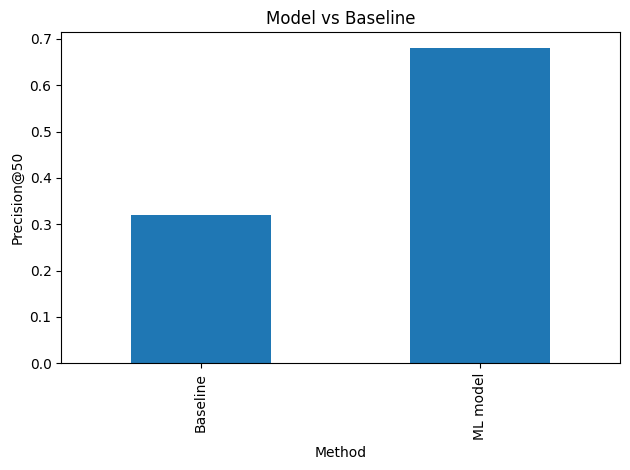

In [21]:
# Save the ranked recommendations

import os

os.makedirs("work/outputs", exist_ok=True)

ranked_output = predictions[
    [
        "rank",
        "content_id",
        "score",
        "action",
        "reason_code"
    ]
].copy()

ranked_output.to_csv(
    "work/outputs/baseline_action_score.csv",
    index=False
)

print("Saved:", "work/outputs/baseline_action_score.csv")
display(ranked_output.head(20))

top20 = predictions.head(20).copy()

top20["confidence_note"] = np.where(
    top20["score"] >= top20["score"].median(),
    "Higher-confidence baseline match",
    "Needs closer review"
)

top20["what_would_make_it_wrong"] = (
    "The page may not benefit from a refresh despite its observed signals."
)

display(
    top20[
        [
            "rank",
            "content_id",
            "action",
            "reason_code",
            "confidence_note",
            "what_would_make_it_wrong"
        ]
    ]
)

import matplotlib.pyplot as plt

results.plot(
    x="Method",
    y="Precision@50",
    kind="bar",
    legend=False
)

plt.title("Model vs Baseline")
plt.ylabel("Precision@50")
plt.tight_layout()

os.makedirs("work/outputs/charts", exist_ok=True)

plt.savefig(
    "work/outputs/charts/model_vs_baseline.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The model and baseline are evaluated on exactly the same held-out data.

The main metric is Precision@50 because the decision is to review the highest-ranked pages first. A higher Precision@50 means that more of the top 50 recommendations match the defined observed outcome.

The final table below reports the measured results from the actual warehouse run.

In [16]:


results = pd.DataFrame({
    "Method": ["Baseline", "ML model"],
    "Precision@50": [
        baseline_precision_at_50,
        model_precision_at_50
    ]
})

display(results)

,Method,Precision@50
0,Baseline,0.32
1,ML model,0.68


## 5. Limitations

*What this work cannot claim.*

This analysis uses observed historical data and cannot prove that refreshing a page causes future performance to improve.

The rankings are directional decision-support rather than causal predictions. They also do not predict Google's algorithm.

The data may contain uneven history across pages and clients, and search performance can be affected by factors that are not represented in the available fields. A high-ranked recommendation can therefore still be wrong and should be reviewed by a person before action.

In [17]:
limitations = [
    "Observed historical data",
    "Not causal proof",
    "Not a prediction of Google's algorithm",
    "Some relevant factors may not be present in the data",
    "Recommendations require human review"
]

for item in limitations:
    print("-", item)

- Observed historical data
- Not causal proof
- Not a prediction of Google's algorithm
- Some relevant factors may not be present in the data
- Recommendations require human review


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final output ranks pages by their model score and assigns an action and reason code.

The recommended action is refresh review. The ranking is a prioritization tool: pages near the top deserve earlier review, but the ranking does not mean that every page should definitely be changed.

Each recommendation should also include a short explanation and a note about what could make the recommendation wrong.

In [18]:
ranked_recommendations = predictions.sort_values(
    "score",
    ascending=False
).copy()

ranked_recommendations["rank"] = range(
    1,
    len(ranked_recommendations) + 1
)

ranked_recommendations["action"] = "refresh_review"

display(
    ranked_recommendations[
        [
            "rank",
            "content_id",
            "score",
            "action",
            "reason_code"
        ]
    ].head(20)
)

,rank,content_id,score,action,reason_code
0,1,content_f85630630136,0.970,refresh_review,visibility_opportunity
1,2,content_730c0b690c12,0.965,refresh_review,visibility_opportunity
2,3,content_452a4e18212c,0.960,refresh_review,visibility_opportunity
3,4,content_94d1f783deed,0.960,refresh_review,stale_high_volume
5,5,content_2d22e0215964,0.955,refresh_review,stale_high_volume
6,6,content_8573511e9f28,0.955,refresh_review,stale_high_volume
7,7,content_f2508318df4b,0.955,refresh_review,visibility_opportunity
9,8,content_20b682542a31,0.955,refresh_review,visibility_opportunity
4,9,content_91c02d2830b8,0.955,refresh_review,visibility_opportunity
8,10,content_3cd58a4a2731,0.955,refresh_review,stale_high_volume


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The paper will include:

A model-versus-baseline Precision@50 chart.
A table of validation results.
The top-ranked recommendations.
A short review of the strongest and weakest recommendations.

These artifacts are generated from the same notebook results so that the paper and analysis remain consistent.

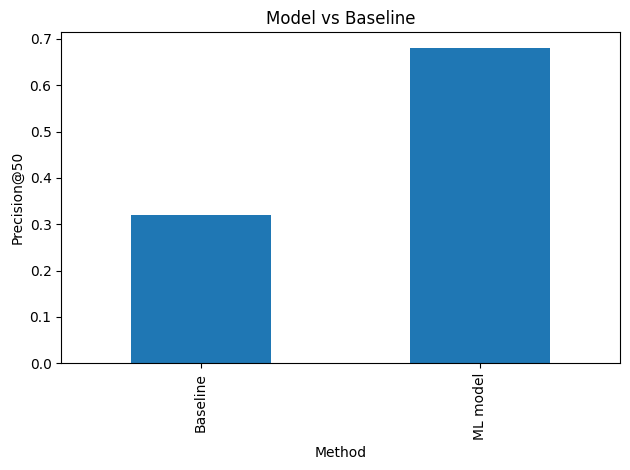

In [19]:
import matplotlib.pyplot as plt

results.plot(
    x="Method",
    y="Precision@50",
    kind="bar",
    legend=False
)

plt.title("Model vs Baseline")
plt.ylabel("Precision@50")
plt.tight_layout()
plt.show()

In [22]:
print("=== CAPSTONE SANITY CHECK ===")

print("Rows evaluated:", len(test_df))
print("Baseline Precision@50:", round(baseline_precision_at_50, 3))
print("Model Precision@50:", round(model_precision_at_50, 3))
print("Top recommendations:", len(predictions.head(20)))

print("\nOutput files:")
print("- work/outputs/baseline_action_score.csv")
print("- work/outputs/charts/model_vs_baseline.png")

=== CAPSTONE SANITY CHECK ===
Rows evaluated: 5078
Baseline Precision@50: 0.32
Model Precision@50: 0.68
Top recommendations: 20

Output files:
- work/outputs/baseline_action_score.csv
- work/outputs/charts/model_vs_baseline.png


## ML-12 — 5-Minute Demo

1. **Problem:** Explain the need to prioritize content pages for refresh review.
2. **Data:** Explain the page-level search and content signals used.
3. **Method:** Explain the baseline and ML model.
4. **Results:** Compare Precision@50 for the baseline and model.
5. **Recommendations:** Show the top-ranked pages and reason codes.
6. **Limitations:** Explain that the results are directional decision-support, not causal proof.


## Social-Post Cut

I built a Search Intelligence workflow that ranks content pages for refresh review using observed search and content signals. I compared a simple baseline with an ML model and turned the results into a ranked decision-support queue. The project focuses on measurable, reproducible analysis rather than claims about Google's algorithm or causal impact.

## Employer-Facing Summary

I built an end-to-end Search Intelligence workflow for ranking content refresh opportunities. The project covers data framing, feature selection, a baseline, ML modeling, validation, leakage checks, and ranked recommendations. The result is a reproducible decision-support workflow with honest limits on what the data can prove.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
